# 05. Modeling - Home Loan Approval Prediction

**Objective
Build and evaluate machine learning models to predict loan approval.

**Models:
- Logistics Regression (baseline)
- Random Forest
- Gradient Boosting

**Evaluation Metrics:
-Accuracy
-Precision, Recall, F1-Score
-Çonfusion Matrix
-ROC-AUC

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

train = pd.read_csv('../data/processed/train_final.csv')
X_test = pd.read_csv('../data/processed/test_final.csv')              

x = train.drop('Loan_Status', axis=1)
y = train['Loan_Status']

print("x shape:", x.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)  


x shape: (614, 14)
y shape: (614,)
X_test shape: (367, 14)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)
                                                 
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)


X_train: (491, 14)
X_val: (123, 14)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_val_scaled = scaler.transform(X_val)

log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(x_train_scaled, y_train)

y_pred_log = log_model.predict(x_val_scaled)
y_prob_log = log_model.predict_proba(x_val_scaled)[:,1]

print("=== Logistic Regression Results ===")
print("Accuracy:", round(accuracy_score(y_val, y_pred_log), 4))
print("ROC-AUC:", round(roc_auc_score(y_val, y_prob_log), 4))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_log))
      

=== Logistic Regression Results ===
Accuracy: 0.8618
ROC-AUC: 0.8015

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [35]:
rf_model= RandomForestClassifier(
   n_estimators=200,
   max_depth=8,
   random_state=42,
   n_jobs=-1
)
 
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
y_prob_rf = rf_model.predict_proba(X_val)[:,1]

print("=== Random Forest Results ===")
print("Accuracy:", round(accuracy_score(y_val, y_pred_rf), 4))
print("ROC-AUcc:", round(roc_auc_score(y_val, y_prob_rf), 4))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf))


=== Random Forest Results ===
Accuracy: 0.8537
ROC-AUcc: 0.8601

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.61      0.72        38
           1       0.85      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



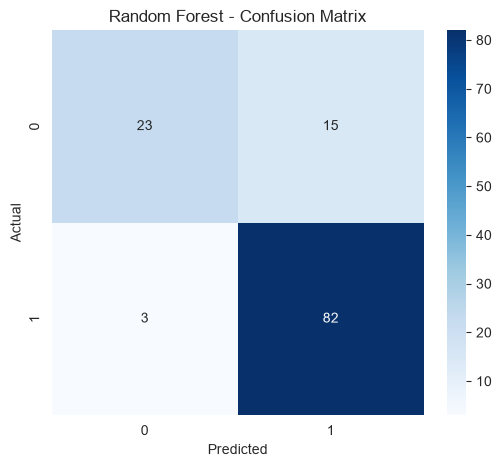

In [37]:
cm = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_51940\2530397030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette='viridis')


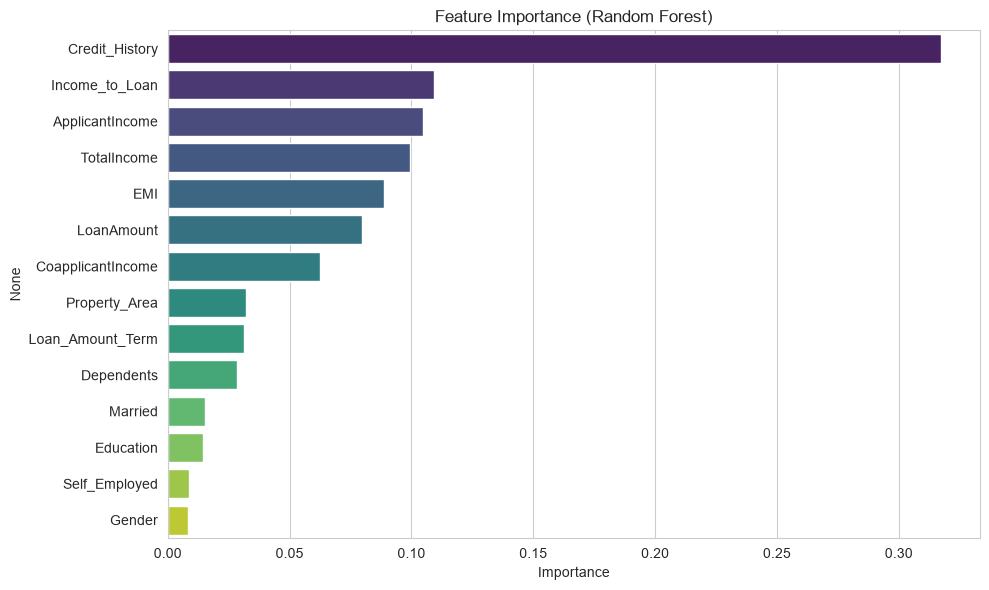

Credit_History       0.3174
Income_to_Loan       0.1093
ApplicantIncome      0.1048
TotalIncome          0.0992
EMI                  0.0887
LoanAmount           0.0796
CoapplicantIncome    0.0625
Property_Area        0.0319
Loan_Amount_Term     0.0315
Dependents           0.0286
Married              0.0152
Education            0.0143
Self_Employed        0.0087
Gender               0.0083
dtype: float64


In [40]:
importance = pd.Series(rf_model.feature_importances_, index=x.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importance.values, y=importance.index, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance.round(4))

### Model Performance Summary

  [Logistics Regression    { Accuracy  0.8618  }     {ROC-AUC  0.8015}]
 [ Random Forest       {  Accuracy      0.8537   }   {ROC-AUC   0.8601}]

  * Both models perform well.
  * Random Forest has a better ROC-AUC.
  * Credit History is by far the most important feature.
  * Other useful features include: Income_To_Loan, ApplicantIncome, TotalIncome, LoanAmount.

Next: Notebook 06.

  